In [235]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [236]:
all_od = 15448914.32101903

In [237]:
#results_path = '../experiment/output/exec2_2023_spot/results.csv'
results_path = 'output/resuts_comp_opt.csv'
results = pd.read_csv(results_path)

In [238]:
results

,bias_level,sd_level,cost,relative_cost
0,0.0,0.0,1.273293e+07,1.000000
1,0.0,0.0,1.275322e+07,1.001594
2,-0.2,0.1,1.291926e+07,1.014634
3,0.2,0.2,1.288313e+07,1.011796
4,-0.2,0.0,1.291284e+07,1.014130
5,-0.1,0.1,1.280228e+07,1.005447
6,-0.2,0.2,1.293901e+07,1.016185
7,0.1,0.1,1.279057e+07,1.004527
8,0.0,0.1,1.275374e+07,1.001635
9,0.1,0.0,1.279939e+07,1.005220


In [239]:
opt_cost = (results[results['relative_cost'] == 1]).iloc[0].tolist()[2]
relative_od_cost = all_od / opt_cost
relative_od_cost

1.2133043928381702

### Final Results

#### Only Bias

In [240]:
results_bias = results[results['sd_level'] == 0]
results_bias = results_bias.sort_values(by=['bias_level'])
results_bias

,bias_level,sd_level,cost,relative_cost
4,-0.2,0.0,1.291284e+07,1.014130
12,-0.1,0.0,1.279830e+07,1.005134
0,0.0,0.0,1.273293e+07,1.000000
1,0.0,0.0,1.275322e+07,1.001594
9,0.1,0.0,1.279939e+07,1.005220
15,0.2,0.0,1.291625e+07,1.014398


In [241]:
results_bias = results_bias[results_bias["relative_cost"] != 1]

In [242]:
results_bias

,bias_level,sd_level,cost,relative_cost
4,-0.2,0.0,1.291284e+07,1.014130
12,-0.1,0.0,1.279830e+07,1.005134
1,0.0,0.0,1.275322e+07,1.001594
9,0.1,0.0,1.279939e+07,1.005220
15,0.2,0.0,1.291625e+07,1.014398


In [243]:
results_bias_sel = results_bias[['bias_level', 'cost']]
results_bias_sel

,bias_level,cost
4,-0.2,1.291284e+07
12,-0.1,1.279830e+07
1,0.0,1.275322e+07
9,0.1,1.279939e+07
15,0.2,1.291625e+07


In [244]:
base_cost = results_bias_sel.loc[results_bias_sel['bias_level'] == 0.0, 'cost'].iloc[0]
results_bias_sel['relative_cost'] = results_bias_sel['cost'] / base_cost
results_bias_sel

/tmp/ipykernel_481136/4032390061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_bias_sel['relative_cost'] = results_bias_sel['cost'] / base_cost


,bias_level,cost,relative_cost
4,-0.2,1.291284e+07,1.012516
12,-0.1,1.279830e+07,1.003535
1,0.0,1.275322e+07,1.000000
9,0.1,1.279939e+07,1.003621
15,0.2,1.291625e+07,1.012784


In [245]:
(float(all_od / base_cost)-1)*100

21.137371211202005

In [246]:
float(all_od - base_cost)

2695695.255299026

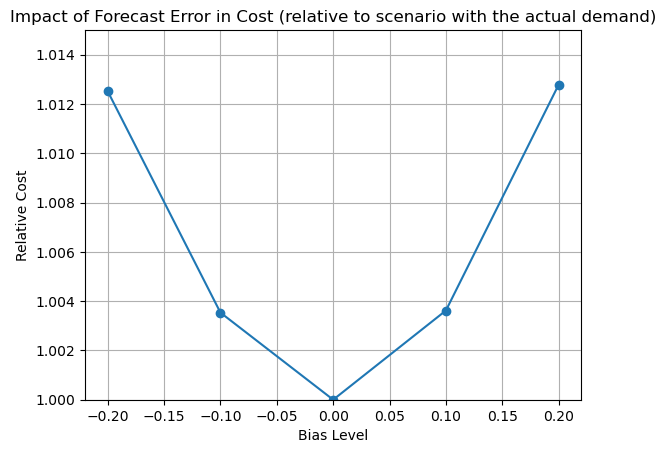

In [247]:
plt.plot(results_bias_sel['bias_level'], results_bias_sel['relative_cost'], marker='o', linestyle='-')

#plt.plot(0, 1, 'ro')
#plt.text(0.005, 1, 'Optimal', color='black', va='bottom', ha='left')

#plt.axhline(y=1.21, color='red', linestyle='--', linewidth=1)
#plt.text(0, 1.01, '100% on-demand', color='black', va='bottom', ha='center')

plt.xlabel('Bias Level')
plt.ylabel('Relative Cost')
plt.title('Impact of Forecast Error in Cost (relative to scenario with the actual demand)')
plt.grid(True)

plt.ylim(1, 1.015)

plt.show()

#### Only SD

In [248]:
results_sd = results[results['bias_level'] == 0]
results_sd = results_sd.sort_values(by=['sd_level'])
results_sd

,bias_level,sd_level,cost,relative_cost
0,0.0,0.0,1.273293e+07,1.000000
1,0.0,0.0,1.275322e+07,1.001594
8,0.0,0.1,1.275374e+07,1.001635
13,0.0,0.2,1.275853e+07,1.002011


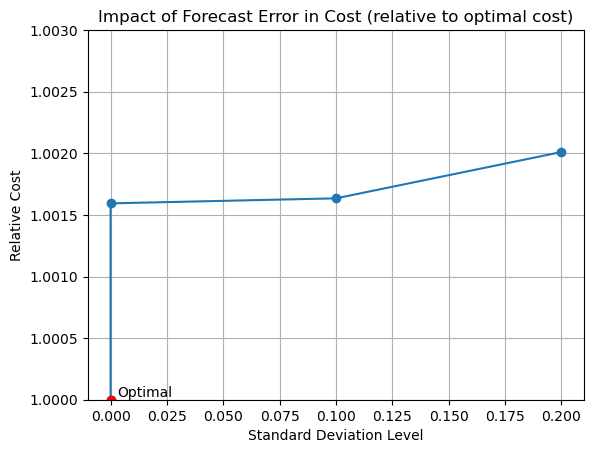

In [249]:
plt.plot(results_sd['sd_level'], results_sd['relative_cost'], marker='o', linestyle='-')

plt.plot(0, 1, 'ro')
plt.text(0.003, 1, 'Optimal', color='black', va='bottom', ha='left')

plt.xlabel('Standard Deviation Level')
plt.ylabel('Relative Cost')
plt.title('Impact of Forecast Error in Cost (relative to optimal cost)')
plt.grid(True)
plt.ylim(1, 1.003)

plt.show()

#### Both

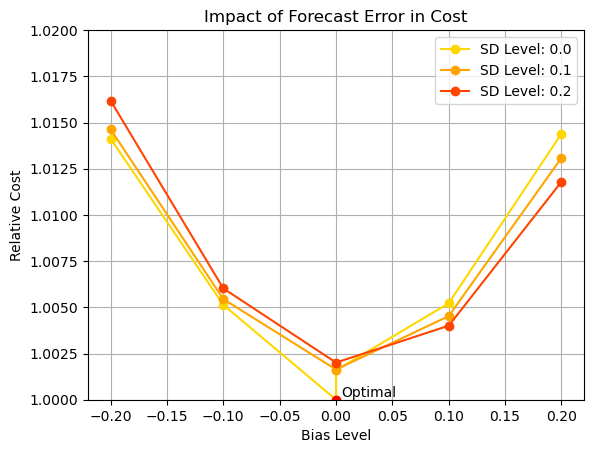

In [250]:
sd_levels = sorted(list(set(results['sd_level'])))
colors = ['gold', 'orange', 'orangered']

for i in range(len(sd_levels)):
    sd_level = sd_levels[i]
    results_sd_level = results[results['sd_level'] == sd_level]
    results_sd_level = results_sd_level.sort_values(by=['bias_level'])
    plt.plot(results_sd_level['bias_level'], results_sd_level['relative_cost'], marker='o', linestyle='-', label=f'SD Level: {sd_level}', color=colors[i])

plt.plot(0, 1, 'ro')
plt.text(0.005, 1, 'Optimal', color='black', va='bottom', ha='left')

plt.ylim(1, 1.02)
plt.xlabel('Bias Level')
plt.ylabel('Relative Cost')
plt.title('Impact of Forecast Error in Cost')
plt.legend()
plt.grid(True)

plt.show()

### Further analysis

#### Demand

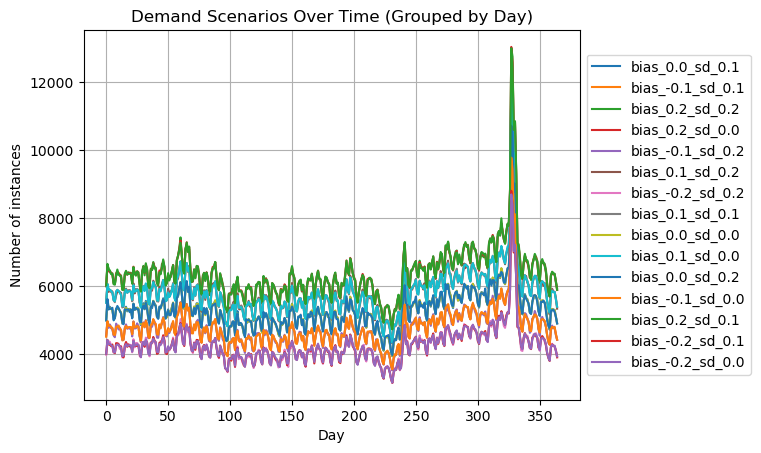

In [251]:
demand_path = 'output/demand'
for demand_file in os.listdir(demand_path):
    demand_file_path = os.path.join(demand_path, demand_file)
    demand_df = pd.read_csv(demand_file_path)
    # Agrupa a cada 24 linhas, tirando a média
    demand_df_grouped = demand_df.groupby(demand_df.index // 24).mean(numeric_only=True)
    legend_alias = demand_file.replace("demand_", "").replace(".csv", "")
    plt.plot(demand_df_grouped.index, demand_df_grouped['num_instances'], label=legend_alias)

plt.xlabel('Day')
plt.ylabel('Number of instances')
plt.title('Demand Scenarios Over Time (Grouped by Day)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # legend outside
plt.grid(True)
plt.show()

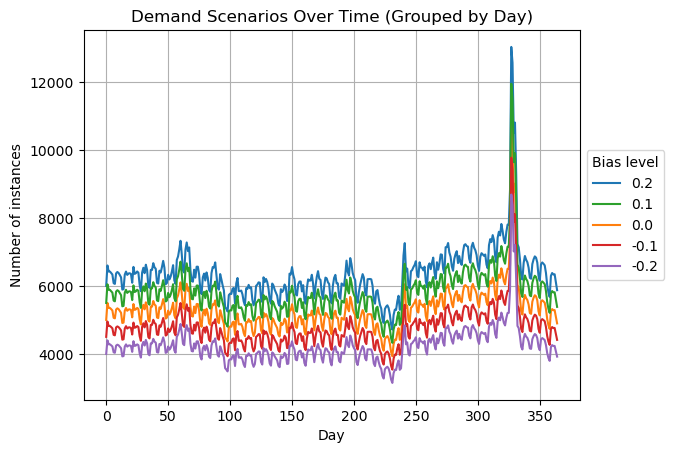

In [252]:
# Only bias

demand_path = 'output/demand'
legend_labels = []
plot_handles = []

for demand_file in os.listdir(demand_path):
    sd = float(demand_file.split('_')[4].replace('.csv', ''))
    if sd != 0: continue

    demand_file_path = os.path.join(demand_path, demand_file)
    demand_df = pd.read_csv(demand_file_path)
    # Agrupa a cada 24 linhas, tirando a média
    demand_df_grouped = demand_df.groupby(demand_df.index // 24).mean(numeric_only=True)
    legend_alias = demand_file.replace("demand_", "").replace(".csv", "").split('_')[1]
    handle, = plt.plot(demand_df_grouped.index, demand_df_grouped['num_instances'], label=legend_alias)
    plot_handles.append(handle)
    legend_labels.append(legend_alias)

desired_order = ['0.2', '0.1', '0.0', '-0.1', '-0.2']
order_indices = [legend_labels.index(lbl) for lbl in desired_order if lbl in legend_labels]
ordered_handles = [plot_handles[i] for i in order_indices]
ordered_labels = [legend_labels[i] for i in order_indices]

plt.xlabel('Day')
plt.ylabel('Number of instances')
plt.title('Demand Scenarios Over Time (Grouped by Day)')
plt.legend(handles=ordered_handles, labels=ordered_labels, title='Bias level', loc='center left', bbox_to_anchor=(1, 0.5))  # legend outside
plt.grid(True)
plt.show()

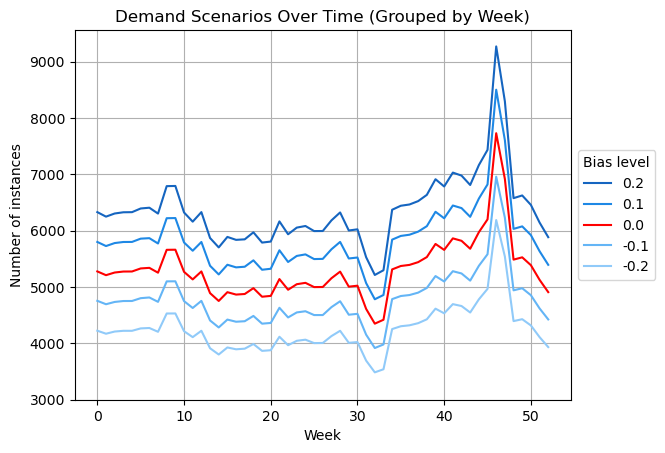

In [253]:
# Only bias

demand_path = 'output/demand'
legend_labels = []
plot_handles = []

# Define the order and colors for each bias scenario
desired_order = ['0.2', '0.1', '0.0', '-0.1', '-0.2']
color_map = {
    '0.2': '#1565c0',    # darkest blue
    '0.1': '#1e88e5',    # medium-dark blue
    '0.0': 'red',        # red for 0.0
    '-0.1': '#64b5f6',   # medium-light blue
    '-0.2': '#90caf9'    # lightest blue
}

for demand_file in os.listdir(demand_path):
    sd = float(demand_file.split('_')[4].replace('.csv', ''))
    if sd != 0: continue

    demand_file_path = os.path.join(demand_path, demand_file)
    demand_df = pd.read_csv(demand_file_path)
    # Agrupa a cada 24*7 linhas, tirando a média
    demand_df_grouped = demand_df.groupby(demand_df.index // (24*7)).mean(numeric_only=True)
    legend_alias = demand_file.replace("demand_", "").replace(".csv", "").split('_')[1]
    color = color_map.get(legend_alias, 'gray')
    handle, = plt.plot(demand_df_grouped.index, demand_df_grouped['num_instances'], label=legend_alias, color=color)
    plot_handles.append(handle)
    legend_labels.append(legend_alias)

order_indices = [legend_labels.index(lbl) for lbl in desired_order if lbl in legend_labels]
ordered_handles = [plot_handles[i] for i in order_indices]
ordered_labels = [legend_labels[i] for i in order_indices]

plt.xlabel('Week')
plt.ylabel('Number of instances')
plt.title('Demand Scenarios Over Time (Grouped by Week)')
plt.legend(handles=ordered_handles, labels=ordered_labels, title='Bias level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.yticks(ticks=range(3000, 9000 + 1, 1000))
plt.show()

#### Savings Plans Purchased

In [254]:
allocations_path = 'output/allocations'
df_sp_purchases = pd.DataFrame()


for scenario in os.listdir(allocations_path):
    scenario_path = os.path.join(allocations_path, scenario)
    scenario_name = os.path.splitext(os.path.basename(scenario_path))[0].replace("alloc_cost_", "").replace("bias", "b").replace("sd", "s")
    allocations = pd.read_csv(scenario_path)
    df_sp_purchases[scenario_name] = allocations['RNo']

In [255]:
baseline_col = "b_0.0_s_0.0"
relative_df = df_sp_purchases.div(df_sp_purchases[baseline_col], axis=0) * 100
print(relative_df.head())

   b_-0.1_s_0.0  b_0.2_s_0.0  b_-0.2_s_0.2  b_0.2_s_0.1  b_0.0_s_0.0  \
0     90.111102   119.480415     75.759906   119.140064        100.0   
1     90.110315   119.466637     78.102976   119.530839        100.0   
2     90.110315   119.466637     78.143351   119.584636        100.0   
3     90.110315   119.466637     78.309393   119.585652        100.0   
4     90.127161   119.466637     78.309393   119.585652        100.0   

   b_-0.2_s_0.0  b_0.1_s_0.1  b_-0.1_s_0.2  b_-0.2_s_0.1  b_0.1_s_0.2  \
0     80.525699   108.288281     86.461102     79.907487   108.534193   
1     80.539294   109.551361     88.112065     80.136411   108.862367   
2     80.539294   109.554981     89.254026     80.259668   109.098713   
3     80.539294   109.554981     89.254026     80.386224   109.098713   
4     80.539294   109.554981     89.375571     80.386224   109.098713   

   b_0.0_s_0.1  b_0.0_s_0.2  b_0.2_s_0.2  b_-0.1_s_0.1  b_0.1_s_0.0  
0    98.321616    96.836842   116.849017     89.106217   1

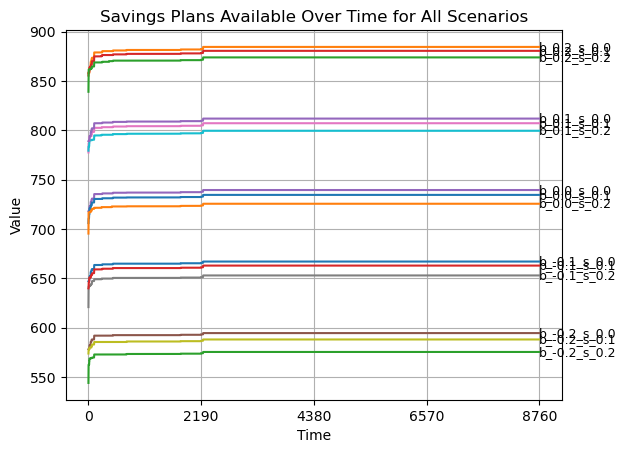

In [256]:
for col in df_sp_purchases.columns:
    line, = plt.plot(df_sp_purchases.index, df_sp_purchases[col])  # use index on x-axis

    # annotate at the last point of the line
    plt.text(
        df_sp_purchases.index[-1],       # x = last index
        df_sp_purchases[col].iloc[-1],   # y = last value
        col,                # column name as label
        color="black",      # <- always black
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Savings Plans Available Over Time for All Scenarios")
plt.grid(True)

plt.xticks(ticks=range(0, len(df_sp_purchases.index) + 1, 2190))

plt.show()



##### Standard Deviation

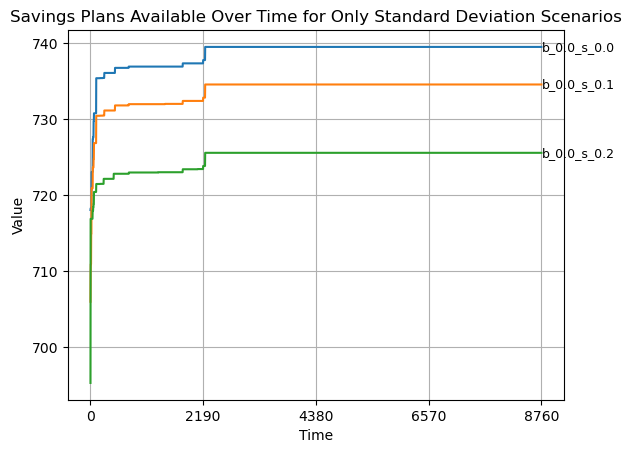

In [257]:
for col in df_sp_purchases.columns:
    bias = float(col.split('_')[1])
    if bias == 0:
        line, = plt.plot(df_sp_purchases.index, df_sp_purchases[col])

        plt.text(
            df_sp_purchases.index[-1],
            df_sp_purchases[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Savings Plans Available Over Time for Only Standard Deviation Scenarios")
plt.grid(True)

plt.xticks(ticks=range(0, len(df_sp_purchases.index) + 1, 2190))

plt.show()

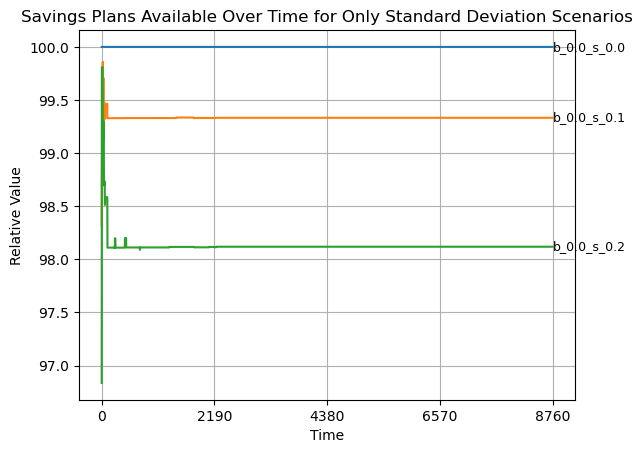

In [258]:
for col in relative_df.columns:
    bias = float(col.split('_')[1])
    if bias == 0:
        line, = plt.plot(relative_df.index, relative_df[col])

        plt.text(
            relative_df.index[-1],
            relative_df[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Only Standard Deviation Scenarios")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df.index) + 1, 2190))

plt.show()

In [259]:
baseline_col = "b_0.1_s_0.0"
df_sp_purchases_tmp = df_sp_purchases[['b_0.1_s_0.0', 'b_0.1_s_0.1', 'b_0.1_s_0.2']]
relative_df_tmp = df_sp_purchases_tmp.div(df_sp_purchases_tmp[baseline_col], axis=0) * 100
print(relative_df_tmp.head())

   b_0.1_s_0.0  b_0.1_s_0.1  b_0.1_s_0.2
0        100.0    98.543345    98.767128
1        100.0    99.688964    99.061997
2        100.0    99.692258    99.277066
3        100.0    99.692258    99.277066
4        100.0    99.692258    99.277066


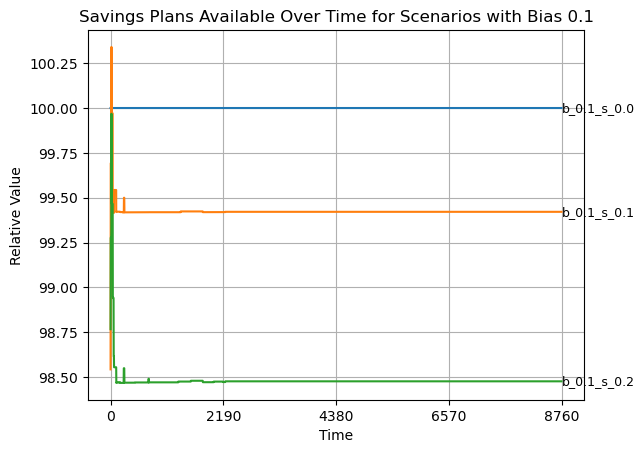

In [260]:
for col in relative_df_tmp.columns:
    line, = plt.plot(relative_df_tmp.index, relative_df_tmp[col])

    plt.text(
        relative_df_tmp.index[-1],
        relative_df_tmp[col].iloc[-1],
        col,
        color="black",
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Scenarios with Bias 0.1")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df_tmp.index) + 1, 2190))

plt.show()

In [261]:
baseline_col = "b_0.2_s_0.0"
df_sp_purchases_tmp = df_sp_purchases[['b_0.2_s_0.0', 'b_0.2_s_0.1', 'b_0.2_s_0.2']]
relative_df_tmp = df_sp_purchases_tmp.div(df_sp_purchases_tmp[baseline_col], axis=0) * 100
print(relative_df_tmp.head())

   b_0.2_s_0.0  b_0.2_s_0.1  b_0.2_s_0.2
0        100.0    99.715141    97.797632
1        100.0   100.053740    98.469354
2        100.0   100.098771    99.429055
3        100.0   100.099622    99.637009
4        100.0   100.099622   100.384379


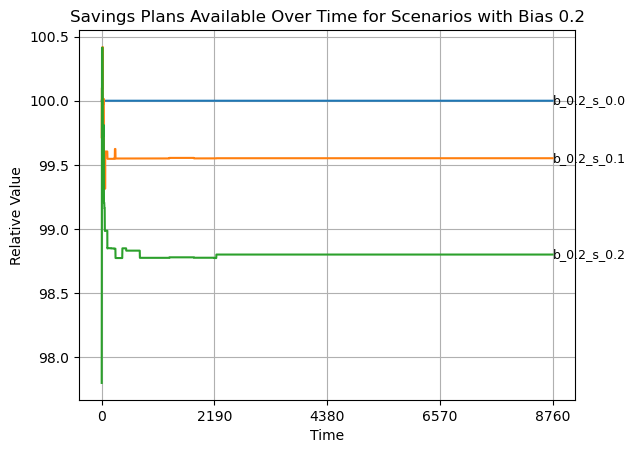

In [262]:
for col in relative_df_tmp.columns:
    line, = plt.plot(relative_df_tmp.index, relative_df_tmp[col])

    plt.text(
        relative_df_tmp.index[-1],
        relative_df_tmp[col].iloc[-1],
        col,
        color="black",
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Scenarios with Bias 0.2")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df_tmp.index) + 1, 2190))

plt.show()

In [263]:
baseline_col = "b_-0.1_s_0.0"
df_sp_purchases_tmp = df_sp_purchases[['b_-0.1_s_0.0', 'b_-0.1_s_0.1', 'b_-0.1_s_0.2']]
relative_df_tmp = df_sp_purchases_tmp.div(df_sp_purchases_tmp[baseline_col], axis=0) * 100
print(relative_df_tmp.head())

   b_-0.1_s_0.0  b_-0.1_s_0.1  b_-0.1_s_0.2
0         100.0     98.884837     95.949444
1         100.0     98.955595     97.782441
2         100.0     98.974136     99.049733
3         100.0     98.974136     99.049733
4         100.0     99.695923     99.166078


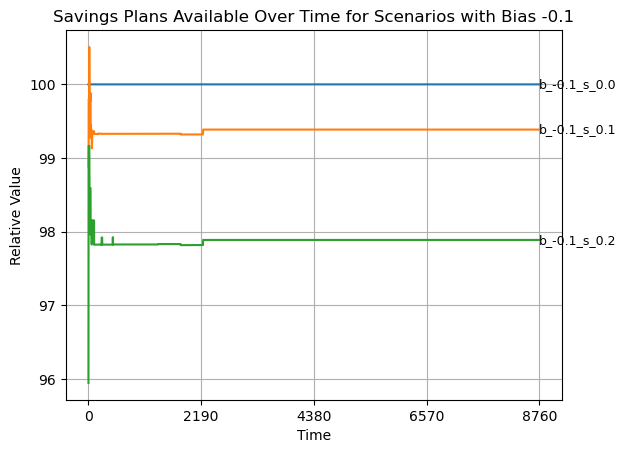

In [264]:
for col in relative_df_tmp.columns:
    line, = plt.plot(relative_df_tmp.index, relative_df_tmp[col])

    plt.text(
        relative_df_tmp.index[-1],
        relative_df_tmp[col].iloc[-1],
        col,
        color="black",
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Scenarios with Bias -0.1")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df_tmp.index) + 1, 2190))

plt.show()

In [265]:
baseline_col = "b_-0.2_s_0.0"
df_sp_purchases_tmp = df_sp_purchases[['b_-0.2_s_0.0', 'b_-0.2_s_0.1', 'b_-0.2_s_0.2']]
relative_df_tmp = df_sp_purchases_tmp.div(df_sp_purchases_tmp[baseline_col], axis=0) * 100
print(relative_df_tmp.head())

   b_-0.2_s_0.0  b_-0.2_s_0.1  b_-0.2_s_0.2
0         100.0     99.232280     94.081649
1         100.0     99.499768     96.974994
2         100.0     99.652808     97.025126
3         100.0     99.809944     97.231288
4         100.0     99.809944     97.231288


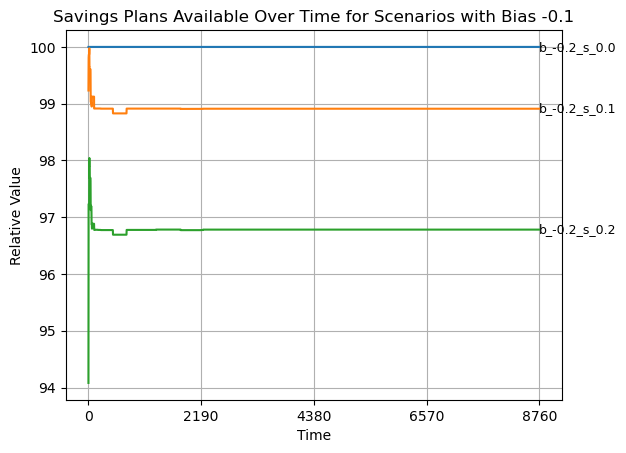

In [266]:
for col in relative_df_tmp.columns:
    line, = plt.plot(relative_df_tmp.index, relative_df_tmp[col])

    plt.text(
        relative_df_tmp.index[-1],
        relative_df_tmp[col].iloc[-1],
        col,
        color="black",
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Scenarios with Bias -0.1")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df_tmp.index) + 1, 2190))

plt.show()

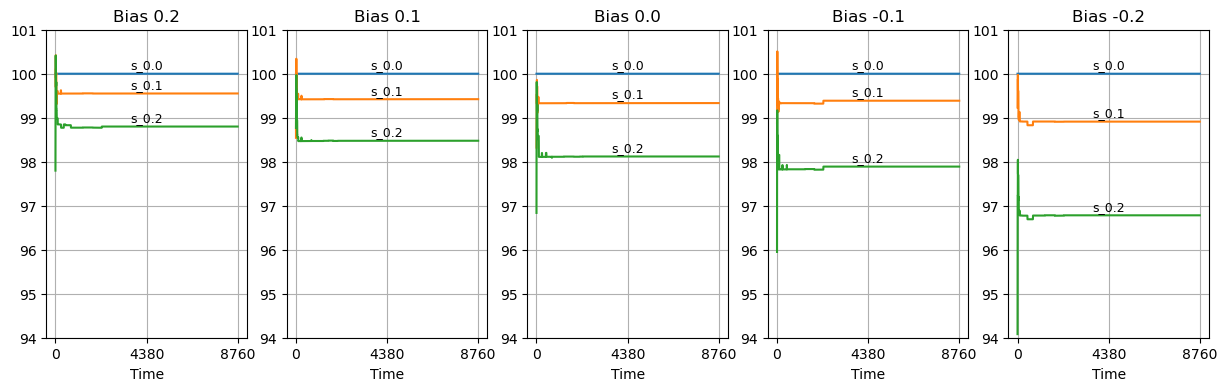

In [267]:
fig, axs = plt.subplots(1, 5, figsize=(15, 4))  # 1 row, 5 columns

bias_levels = ['0.2', '0.1','0.0', '-0.1', '-0.2']
for i, bias_level in enumerate(bias_levels):
    baseline_col = f"b_{bias_level}_s_0.0"
    df_sp_purchases_tmp = df_sp_purchases[[f'b_{bias_level}_s_0.0', f'b_{bias_level}_s_0.1', f'b_{bias_level}_s_0.2']]
    relative_df_tmp = df_sp_purchases_tmp.div(df_sp_purchases_tmp[baseline_col], axis=0) * 100

    for col in relative_df_tmp.columns:
        line, = axs[i].plot(relative_df_tmp.index, relative_df_tmp[col])

        relative = (relative_df_tmp[col] / relative_df_tmp[baseline_col]) * 100
        mid_idx = len(relative_df_tmp.index) // 2
        x_mid = relative_df_tmp.index[mid_idx]
        y_mid = relative.iloc[mid_idx]

        axs[i].annotate(
            f's_{col.split('_')[3]}',
            xy=(x_mid, y_mid + 0.05),
            color="black",
            fontsize=9,
            va="bottom", ha="center"
        )

    axs[i].set_xlabel("Time")
    axs[i].set_title(f"Bias {bias_level}")
    axs[i].grid(True)

    axs[i].set_ylim(94, 101)

    axs[i].set_xticks(ticks=range(0, len(relative_df_tmp.index) + 1, 2190*2))

Aumentar a variabilidade da demanda aumenta o custo por diminuir a quantidade de compras de savings plans, o que aumenta a quantidade de instâncias compradas em on-demand (TODO: gráfico). Porém, comparando os cenários com diferentes níveis de viés, o nível de savings plans relativo comprado nos cenários com maior variabilidade varia, há casos em que ele é 97% do cenário base e casos em que é 99%. Quanto maior o viés, a compra de savings plans é mais próxima do cenário base com a mudança na variabilidade.

No início do período, os cenários com maior variabilidade reservam mais savings plans, e, ao longo do tempo, passam a ficar com menos savings plans em comparação com o cenário base (sd = 0.0). O gráfico com os valores absolutos mostra que o nível de savings plans cresce rapidamente no incío do período, para todos os cenários. Isso significa que, para cenários com maior variabilidade, esse nível cresce ainda mais rápido, mas, depois, se estabiliza em um nível menor que os cenários base. Esse crescimento mais rápido pode ser interessante de ser analisado, apesar de que a diferença é bem pequena.

##### Bias

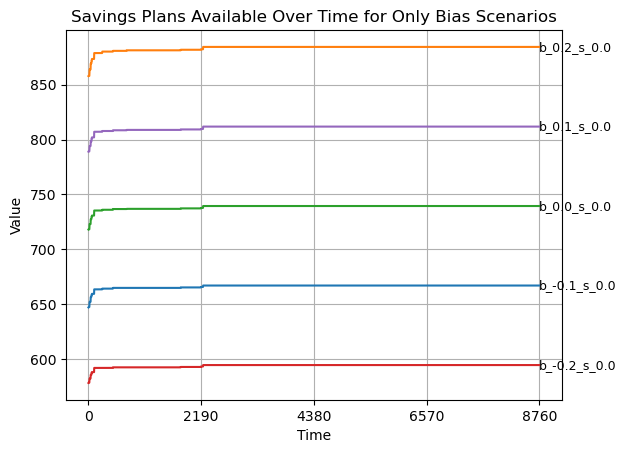

In [268]:
for col in df_sp_purchases.columns:
    sd = float(col.split('_')[3])
    if sd == 0:
        line, = plt.plot(df_sp_purchases.index, df_sp_purchases[col])

        plt.text(
            df_sp_purchases.index[-1],
            df_sp_purchases[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Savings Plans Available Over Time for Only Bias Scenarios")
plt.grid(True)

plt.xticks(ticks=range(0, len(df_sp_purchases.index) + 1, 2190))

plt.show()

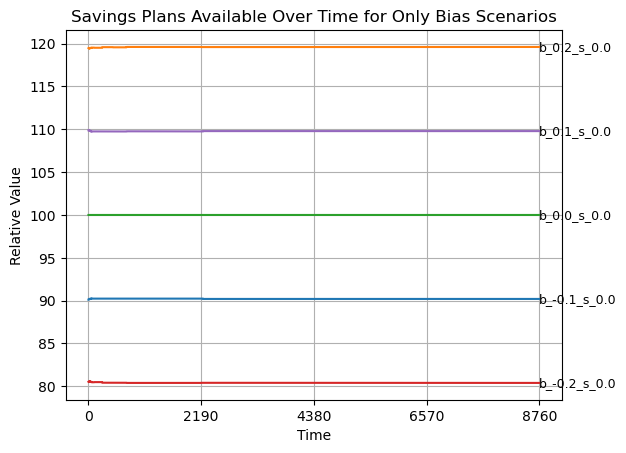

In [269]:
for col in relative_df.columns:
    sd = float(col.split('_')[3])
    if sd == 0:
        line, = plt.plot(relative_df.index, relative_df[col])

        plt.text(
            relative_df.index[-1],
            relative_df[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time for Only Bias Scenarios")
plt.grid(True)

plt.xticks(ticks=range(0, len(relative_df.index) + 1, 2190))

plt.show()

#### Idle Savings Plans

In [270]:
sp_usage_path = 'output/sp_usage'
df_sp_used = pd.DataFrame()

for scenario in os.listdir(sp_usage_path):
    scenario_path = os.path.join(sp_usage_path, scenario)
    scenario_name = os.path.splitext(os.path.basename(scenario_path))[0].replace("sp_usage_", "").replace("bias", "b").replace("sd", "s")
    sp_used = pd.read_csv(scenario_path)
    df_sp_used[scenario_name] = sp_used['value_used']

In [271]:
df_sp_used = df_sp_used[['b_0.0_s_0.0', 'b_0.0_s_0.1', 'b_0.0_s_0.2', 'b_0.1_s_0.0', 'b_0.1_s_0.1', 'b_0.1_s_0.2', 'b_0.2_s_0.0', 'b_0.2_s_0.1', 'b_0.2_s_0.2', 'b_-0.1_s_0.0', 'b_-0.1_s_0.1', 'b_-0.1_s_0.2', 'b_-0.2_s_0.0', 'b_-0.2_s_0.1', 'b_-0.2_s_0.2']]
df_sp_purchases = df_sp_purchases[['b_0.0_s_0.0', 'b_0.0_s_0.1', 'b_0.0_s_0.2', 'b_0.1_s_0.0', 'b_0.1_s_0.1', 'b_0.1_s_0.2', 'b_0.2_s_0.0', 'b_0.2_s_0.1', 'b_0.2_s_0.2', 'b_-0.1_s_0.0', 'b_-0.1_s_0.1', 'b_-0.1_s_0.2', 'b_-0.2_s_0.0', 'b_-0.2_s_0.1', 'b_-0.2_s_0.2']]

In [272]:
idle_values = pd.DataFrame()
for col in df_sp_used.columns:
    idle_values[col] = df_sp_purchases[col] - df_sp_used[col]

In [273]:
baseline_col = "b_0.0_s_0.0"
idle_values_relative = idle_values.div(idle_values[baseline_col], axis=0) * 100
print(idle_values_relative.head())

   b_0.0_s_0.0  b_0.0_s_0.1  b_0.0_s_0.2  b_0.1_s_0.0  b_0.1_s_0.1  \
0        100.0   118.235179   347.462206   714.943266   462.051891   
1        100.0    65.585251   211.471802   268.852482   268.001948   
2        100.0    78.082007   182.845274   236.513378   236.435836   
3        100.0    80.025320   153.112966   186.306607   186.397677   
4        100.0    88.508970   159.873638   197.982992   196.811061   

   b_0.1_s_0.2  b_0.2_s_0.0  b_0.2_s_0.1  b_0.2_s_0.2  b_-0.1_s_0.0  \
0   683.477008  1411.763139  1431.947394  1057.504748    103.053622   
1   277.793695   450.453318   483.110521   404.704583     46.631542   
2   258.544120   380.855790   409.380685   402.455175     43.883558   
3   200.865484   285.153973   302.558559   304.555184     46.072134   
4   217.600187   314.753123   334.484644   370.426272     59.041795   

   b_-0.1_s_0.1  b_-0.1_s_0.2  b_-0.2_s_0.0  b_-0.2_s_0.1  b_-0.2_s_0.2  
0    102.566178     96.629241     92.037243    105.402886     94.675610  
1   

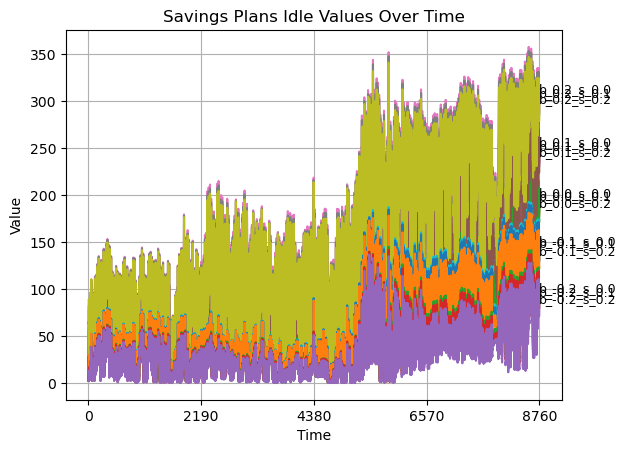

In [274]:
for col in idle_values.columns:
    line, = plt.plot(idle_values.index, idle_values[col])

    plt.text(
        idle_values.index[-1],
        idle_values[col].iloc[-1],
        col,
        color="black",
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Savings Plans Idle Values Over Time")
plt.grid(True)

plt.xticks(ticks=range(0, len(idle_values.index) + 1, 2190))

plt.show()

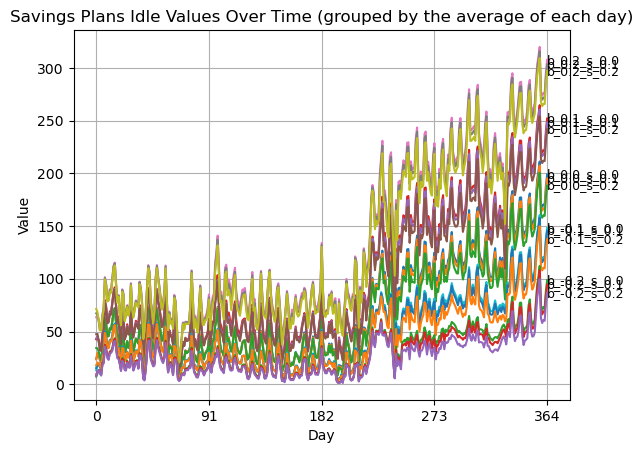

In [275]:
#plt.figure(figsize=(10, 7)) 

n = 24
idle_values_grouped = idle_values.groupby(idle_values.index // n).mean()

for col in idle_values_grouped.columns:
    line, = plt.plot(idle_values_grouped.index, idle_values_grouped[col])

    plt.text(
        idle_values_grouped.index[-1],
        idle_values_grouped[col].iloc[-1],
        col,
        color="black",
        fontsize=9,
        va="center", ha="left"
    )

plt.xlabel("Day")
plt.ylabel("Value")
plt.title("Savings Plans Idle Values Over Time (grouped by the average of each day)")
plt.grid(True)

plt.xticks(ticks=range(0, len(idle_values_grouped.index) + 1, int(2190/24)))

plt.show()

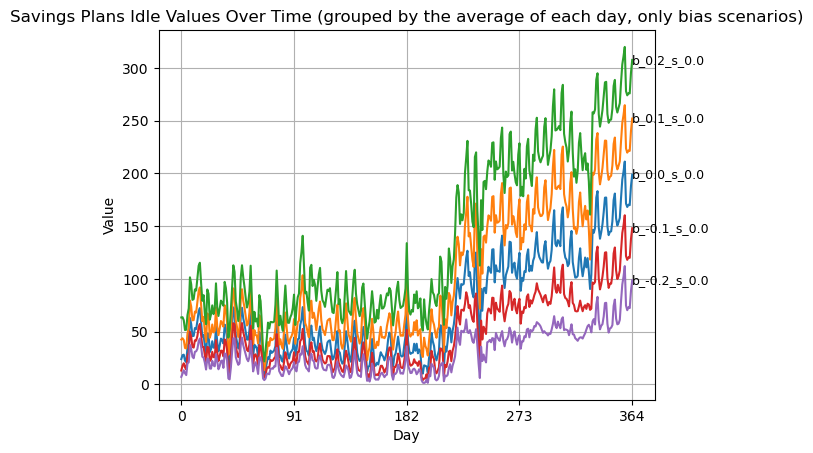

In [276]:
#plt.figure(figsize=(10, 7))
n = 24
idle_values_grouped = idle_values.groupby(idle_values.index // n).mean()

for col in idle_values_grouped.columns:
    sd = float(col.split('_')[3])
    if sd == 0:
        line, = plt.plot(idle_values_grouped.index, idle_values_grouped[col])

        plt.text(
            idle_values_grouped.index[-1],
            idle_values_grouped[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Day")
plt.ylabel("Value")
plt.title("Savings Plans Idle Values Over Time (grouped by the average of each day, only bias scenarios)")
plt.grid(True)

plt.xticks(ticks=range(0, len(idle_values_grouped.index) + 1, int(2190/24)))

plt.show()

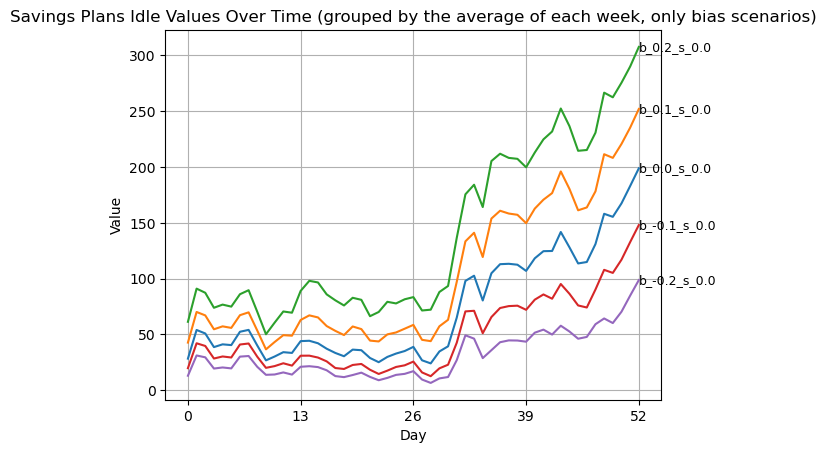

In [277]:
#plt.figure(figsize=(10, 7))
n = 24*7
idle_values_grouped = idle_values.groupby(idle_values.index // n).mean()

for col in idle_values_grouped.columns:
    sd = float(col.split('_')[3])
    if sd == 0:
        line, = plt.plot(idle_values_grouped.index, idle_values_grouped[col])

        plt.text(
            idle_values_grouped.index[-1],
            idle_values_grouped[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Day")
plt.ylabel("Value")
plt.title("Savings Plans Idle Values Over Time (grouped by the average of each week, only bias scenarios)")
plt.grid(True)

plt.xticks(ticks=range(0, len(idle_values_grouped.index) + 1, int(2190/(24*7))))

plt.show()

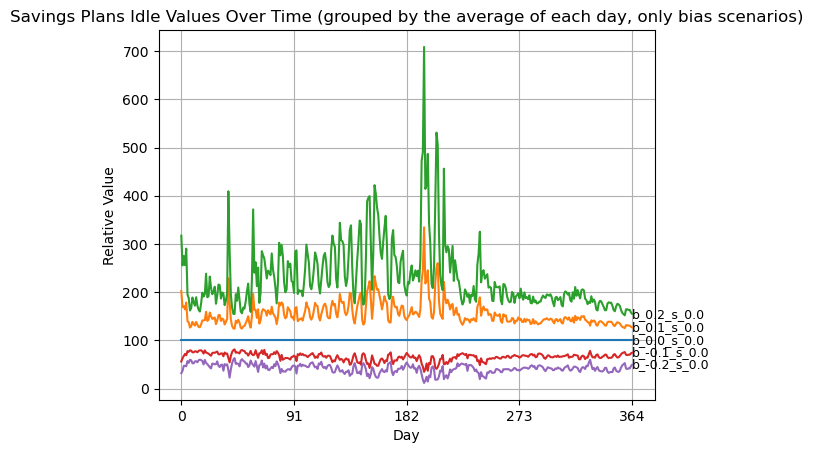

In [278]:
#plt.figure(figsize=(10, 7))
n = 24
idle_values_grouped = idle_values_relative.groupby(idle_values_relative.index // n).mean()

for col in idle_values_grouped.columns:
    sd = float(col.split('_')[3])
    if sd == 0:
        line, = plt.plot(idle_values_grouped.index, idle_values_grouped[col])

        plt.text(
            idle_values_grouped.index[-1],
            idle_values_grouped[col].iloc[-1],
            col,
            color="black",
            fontsize=9,
            va="center", ha="left"
        )

plt.xlabel("Day")
plt.ylabel("Relative Value")
plt.title("Savings Plans Idle Values Over Time (grouped by the average of each day, only bias scenarios)")
plt.grid(True)

plt.xticks(ticks=range(0, len(idle_values_grouped.index) + 1, int(2190/24)))

plt.show()

#### Scenario Analysis - overforecasting

Tracking one scenario to better understand the results.

In [279]:
scenario = 'bias_0.2_sd_0.0'
base_scenario = 'bias_0.0_sd_0.0'
color_scenario = '#1565c0'
color_base = 'red'

##### Demand

In [280]:
demand_path = 'output/demand'
scenario_demand_path = os.path.join(demand_path, f'demand_{scenario}.csv.csv')
base_demand_path = os.path.join(demand_path, f'demand_{base_scenario}.csv.csv')

df_scenario_demand = pd.read_csv(scenario_demand_path)
df_base_demand = pd.read_csv(base_demand_path)

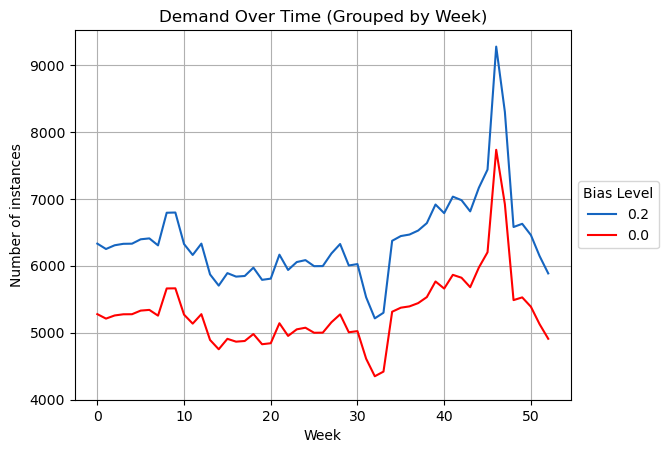

In [281]:
scenario_grouped = df_scenario_demand.groupby(df_scenario_demand.index // (24*7)).mean(numeric_only=True)
base_grouped = df_base_demand.groupby(df_base_demand.index // (24*7)).mean(numeric_only=True)

plt.plot(scenario_grouped.index, scenario_grouped['num_instances'], label='0.2', color=color_scenario)
plt.plot(base_grouped.index, base_grouped['num_instances'], label='0.0', color=color_base)

plt.xlabel('Week')
plt.ylabel('Number of instances')
plt.title('Demand Over Time (Grouped by Week)')
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.yticks(ticks=range(4000, 9000 + 1, 1000))
plt.grid(True)
plt.show()

##### Savings Plans Purchases

In [282]:
allocations_path = 'output/allocations'
df_sp_purchases = pd.DataFrame()

scenario_path = os.path.join(allocations_path, f'alloc_cost_{scenario}.csv')
allocations_scenario = pd.read_csv(scenario_path)

base_path = os.path.join(allocations_path, f'alloc_cost_{base_scenario}.csv')
allocations_base = pd.read_csv(base_path)

df_sp_purchases[scenario] = allocations_scenario['RNo']
df_sp_purchases[base_scenario] = allocations_base['RNo']



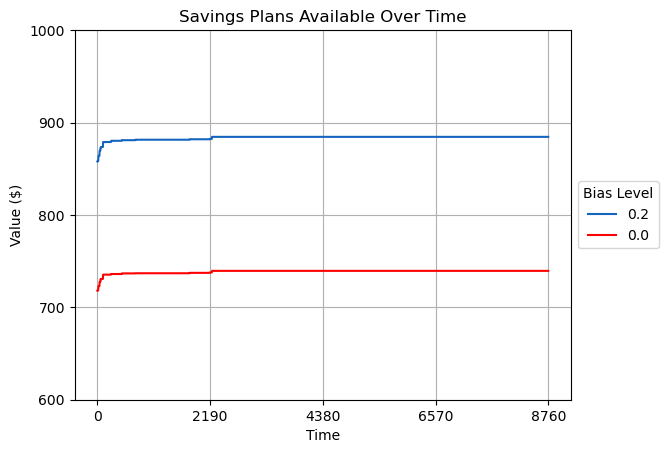

In [283]:
plt.plot(df_sp_purchases.index, df_sp_purchases[scenario], label='0.2', color=color_scenario)
plt.plot(df_sp_purchases.index, df_sp_purchases[base_scenario], label='0.0', color=color_base)

plt.xlabel("Time")
plt.ylabel("Value ($)")
plt.title("Savings Plans Available Over Time")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.xticks(ticks=range(0, len(df_sp_purchases.index) + 1, 2190))
plt.yticks(ticks=range(600, 1000+1, 100))

plt.show()

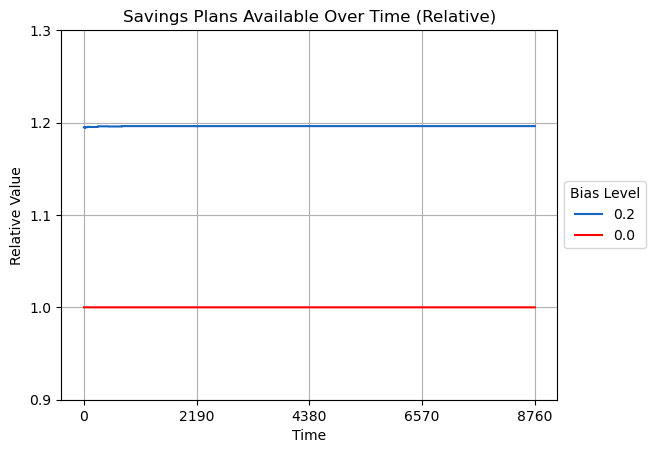

In [284]:
df_relative_sp_purchases = df_sp_purchases.div(df_sp_purchases[base_scenario], axis=0)

plt.plot(df_relative_sp_purchases.index, df_relative_sp_purchases[scenario], label='0.2', color=color_scenario)
plt.plot(df_relative_sp_purchases.index, df_relative_sp_purchases[base_scenario], label='0.0', color=color_base)

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time (Relative)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.xticks(ticks=range(0, len(df_relative_sp_purchases.index) + 1, 2190))
#plt.yticks(ticks=[0.7, 0.8, 0.90, 1.00, 1.10, 1.20, 1.30])
plt.yticks(ticks=[0.90, 1.00, 1.10, 1.20, 1.30])


plt.show()

##### Idle Savings Plans

In [285]:
sp_usage_path = 'output/sp_usage'
df_sp_used = pd.DataFrame()

scenario_path = os.path.join(sp_usage_path, f'sp_usage_{scenario}.csv')
sp_used_scenario = pd.read_csv(scenario_path)

base_path = os.path.join(sp_usage_path, f'sp_usage_{base_scenario}.csv')
sp_used_base = pd.read_csv(base_path)

df_sp_used[scenario] = sp_used_scenario['value_used']
df_sp_used[base_scenario] = sp_used_base['value_used']

df_sp_idle = pd.DataFrame()
for col in df_sp_used.columns:
    df_sp_idle[col] = df_sp_purchases[col] - df_sp_used[col]

In [286]:
df_sp_idle.head()

,bias_0.2_sd_0.0,bias_0.0_sd_0.0
0,40.28692,2.85366
1,48.01463,10.65918
2,52.35735,13.74729
3,61.55884,21.58793
4,59.93551,19.04207


In [287]:
print('Idle SP - 0.2:', float(df_sp_idle[[scenario]].sum()))
print('Idle SP - 0.0:', float(df_sp_idle[[base_scenario]].sum()))

Idle SP - 0.2: 1190647.9408799997
Idle SP - 0.0: 627000.4871400009


/tmp/ipykernel_481136/1836309240.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Idle SP - 0.2:', float(df_sp_idle[[scenario]].sum()))
/tmp/ipykernel_481136/1836309240.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Idle SP - 0.0:', float(df_sp_idle[[base_scenario]].sum()))


In [288]:
print('Used SP - 0.2:', float(df_sp_used[[scenario]].sum()))
print('Used SP - 0.0:', float(df_sp_used[[base_scenario]].sum()))

Used SP - 0.2: 6548535.00768
Used SP - 0.0: 5843527.2287099995


/tmp/ipykernel_481136/1820300653.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Used SP - 0.2:', float(df_sp_used[[scenario]].sum()))
/tmp/ipykernel_481136/1820300653.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Used SP - 0.0:', float(df_sp_used[[base_scenario]].sum()))


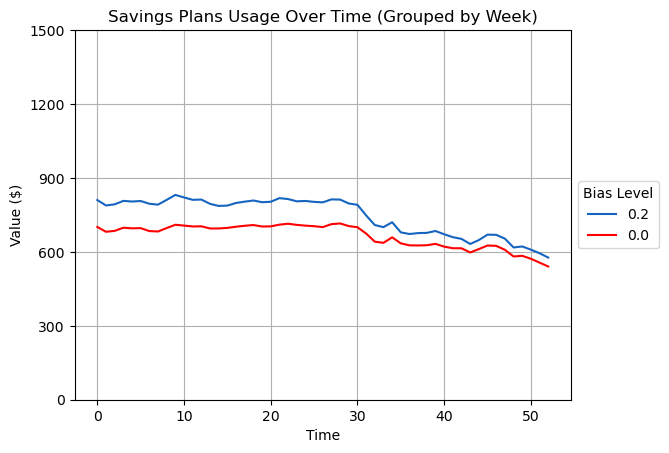

In [289]:
n = 24*7
df_sp_used_grouped = df_sp_used.groupby(df_sp_used.index // n).mean()

plt.plot(df_sp_used_grouped.index, df_sp_used_grouped[scenario], label='0.2', color=color_scenario)
plt.plot(df_sp_used_grouped.index, df_sp_used_grouped[base_scenario], label='0.0', color=color_base)

plt.xlabel("Time")
plt.ylabel("Value ($)")
plt.title("Savings Plans Usage Over Time (Grouped by Week)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.yticks(ticks=range(0, 1500+1, 300))

plt.show()

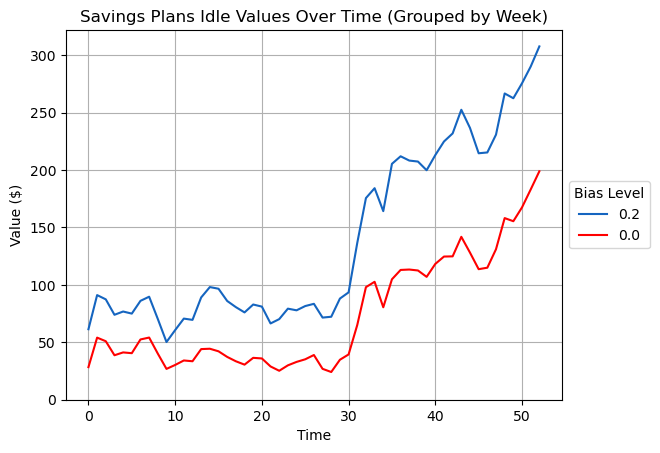

In [290]:
n = 24*7
df_sp_idle_grouped = df_sp_idle.groupby(df_sp_idle.index // n).mean()

plt.plot(df_sp_idle_grouped.index, df_sp_idle_grouped[scenario], label='0.2', color=color_scenario)
plt.plot(df_sp_idle_grouped.index, df_sp_idle_grouped[base_scenario], label='0.0', color=color_base)

plt.xlabel("Time")
plt.ylabel("Value ($)")
plt.title("Savings Plans Idle Values Over Time (Grouped by Week)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.yticks(ticks=range(0, 300 + 1, 50))

plt.show()

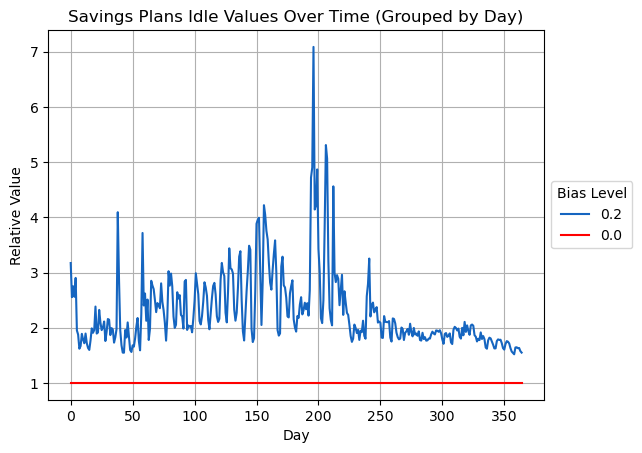

In [291]:
df_sp_idle_relative = df_sp_idle.div(df_sp_idle[base_scenario], axis=0)

n = 24
df_sp_idle_relative_grouped = df_sp_idle_relative.groupby(df_sp_idle_relative.index // n).mean()

plt.plot(df_sp_idle_relative_grouped.index, df_sp_idle_relative_grouped[scenario], label='0.2', color=color_scenario)
plt.plot(df_sp_idle_relative_grouped.index, df_sp_idle_relative_grouped[base_scenario], label='0.0', color=color_base)

plt.xlabel("Day")
plt.ylabel("Relative Value")
plt.title("Savings Plans Idle Values Over Time (Grouped by Day)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.yticks(ticks=range(1, 8, 1))

plt.show()

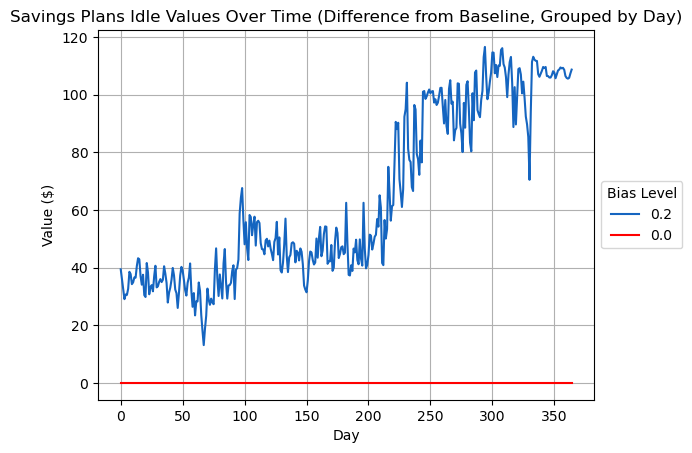

In [292]:
df_sp_idle_diff = df_sp_idle.sub(df_sp_idle[base_scenario], axis=0)

n = 24
df_sp_idle_diff_grouped = df_sp_idle_diff.groupby(df_sp_idle_diff.index // n).mean()

plt.plot(df_sp_idle_diff_grouped.index, df_sp_idle_diff_grouped[scenario], label='0.2', color=color_scenario)
plt.plot(df_sp_idle_diff_grouped.index, df_sp_idle_diff_grouped[base_scenario], label='0.0', color=color_base)

plt.xlabel("Day")
plt.ylabel("Value ($)")
plt.title("Savings Plans Idle Values Over Time (Difference from Baseline, Grouped by Day)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

#plt.yticks(ticks=range(1, 8, 1))

plt.show()

In [293]:
df_sp_idle.head()

,bias_0.2_sd_0.0,bias_0.0_sd_0.0
0,40.28692,2.85366
1,48.01463,10.65918
2,52.35735,13.74729
3,61.55884,21.58793
4,59.93551,19.04207


In [294]:
df_sp_idle[scenario] = pd.to_numeric(df_sp_idle[scenario], errors="coerce")
total_idle_scenario = df_sp_idle[scenario].sum()
print(total_idle_scenario)

1190647.9408799997


In [295]:
df_sp_idle[base_scenario] = pd.to_numeric(df_sp_idle[base_scenario], errors="coerce")
total_idle_base = df_sp_idle[base_scenario].sum()
print(total_idle_base)

627000.4871400009


In [296]:
print(total_idle_scenario - total_idle_base)

563647.4537399987


In [297]:
print(total_idle_scenario / total_idle_base)

1.8989585579287496


##### On-Demand Usage

In [298]:
allocations_path = 'output/allocations'
df_od_usage = pd.DataFrame()

scenario_path = os.path.join(allocations_path, f'alloc_cost_{scenario}.csv')
allocations_scenario = pd.read_csv(scenario_path)

base_path = os.path.join(allocations_path, f'alloc_cost_{base_scenario}.csv')
allocations_base = pd.read_csv(base_path)

df_od_usage[scenario] = allocations_scenario['OnDemand']
df_od_usage[base_scenario] = allocations_base['OnDemand']

In [299]:
allocations_scenario.head()

,timestamp,OnDemand,RAll,RPartialUp,RPartialHr,RNo,AllMarkets
0,0,465.15143,0.0,0.0,0.0,857.92164,1323.07307
1,1,396.45563,0.0,0.0,0.0,858.07574,1254.53137
2,2,458.61633,0.0,0.0,0.0,858.07574,1316.69207
3,3,417.60683,0.0,0.0,0.0,858.07574,1275.68257
4,4,408.20453,0.0,0.0,0.0,858.07574,1266.28027


In [300]:

float(allocations_base[['RNo']].sum())

/tmp/ipykernel_481136/3976553212.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(allocations_base[['RNo']].sum())


6470527.715850002

In [301]:
df_od_usage.head()

,bias_0.2_sd_0.0,bias_0.0_sd_0.0
0,465.15143,626.71403
1,396.45563,558.14383
2,458.61633,618.30853
3,417.60683,575.14183
4,408.20453,564.16893


In [302]:
df_od_usage[scenario] = pd.to_numeric(df_od_usage[scenario], errors="coerce")
total_usage_scenario = df_od_usage[scenario].sum()
print(total_usage_scenario)

5168198.7871199995


In [303]:
df_od_usage[base_scenario] = pd.to_numeric(df_od_usage[base_scenario], errors="coerce")
total_usage_base = df_od_usage[base_scenario].sum()
print(total_usage_base)

6275532.38372


In [304]:
print(total_usage_base - total_usage_scenario)

1107333.5966000007


In [305]:
print(total_usage_scenario / total_usage_base)

0.8235474651564785


In [306]:
print(float(allocations_scenario[['OnDemand']].sum()))
print(float(allocations_scenario[['RNo']].sum()))
print(float(allocations_scenario[['AllMarkets']].sum()))

5168198.7871199995
7739182.948560001
12907381.735679999


/tmp/ipykernel_481136/1208789045.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_scenario[['OnDemand']].sum()))
/tmp/ipykernel_481136/1208789045.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_scenario[['RNo']].sum()))
/tmp/ipykernel_481136/1208789045.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_scenario[['AllMarkets']].sum()))


In [307]:
print(float(allocations_base[['OnDemand']].sum()))
print(float(allocations_base[['RNo']].sum()))
print(float(allocations_base[['AllMarkets']].sum()))

6275532.38372
6470527.715850002
12746060.099569999


/tmp/ipykernel_481136/2071417821.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_base[['OnDemand']].sum()))
/tmp/ipykernel_481136/2071417821.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_base[['RNo']].sum()))
/tmp/ipykernel_481136/2071417821.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_base[['AllMarkets']].sum()))


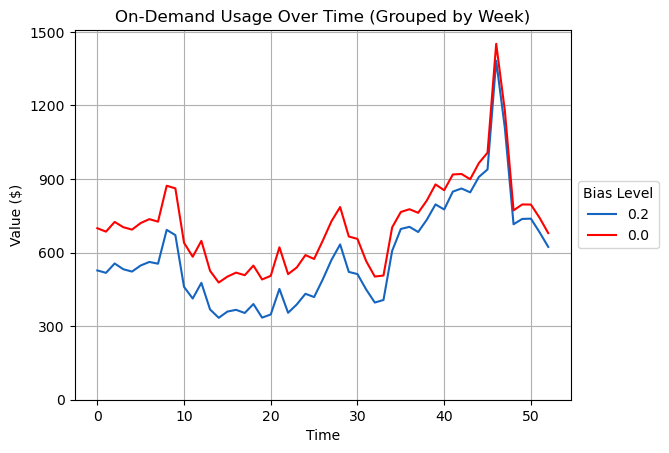

In [308]:
n = 24*7
df_od_usage_grouped = df_od_usage.groupby(df_od_usage.index // n).mean()

plt.plot(df_od_usage_grouped.index, df_od_usage_grouped[scenario], label='0.2', color=color_scenario)
plt.plot(df_od_usage_grouped.index, df_od_usage_grouped[base_scenario], label='0.0', color=color_base)

plt.xlabel("Time")
plt.ylabel("Value ($)")
plt.title("On-Demand Usage Over Time (Grouped by Week)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.yticks(ticks=range(0, 1500+1, 300))

plt.show()

#### Scenario analysis - underforecasting

In [309]:
scenario = 'bias_-0.2_sd_0.0'
base_scenario = 'bias_0.0_sd_0.0'
color_scenario = '#1565c0'
color_base = 'red'

##### Demand

In [310]:
demand_path = 'output/demand'
scenario_demand_path = os.path.join(demand_path, f'demand_{scenario}.csv.csv')
base_demand_path = os.path.join(demand_path, f'demand_{base_scenario}.csv.csv')

df_scenario_demand = pd.read_csv(scenario_demand_path)
df_base_demand = pd.read_csv(base_demand_path)

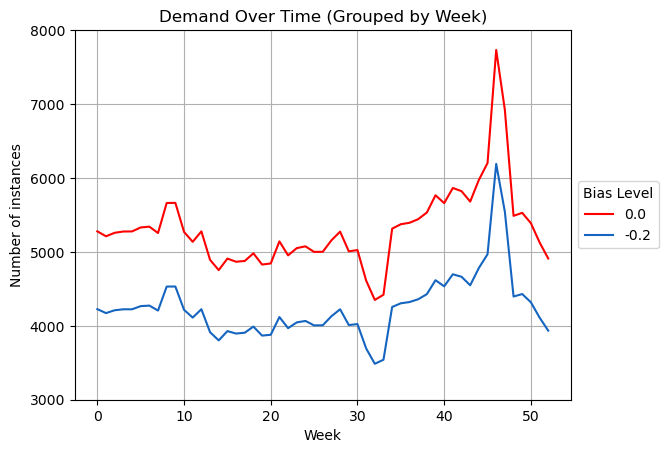

In [341]:
scenario_grouped = df_scenario_demand.groupby(df_scenario_demand.index // (24*7)).mean(numeric_only=True)
base_grouped = df_base_demand.groupby(df_base_demand.index // (24*7)).mean(numeric_only=True)

plt.plot(base_grouped.index, base_grouped['num_instances'], label='0.0', color=color_base)
plt.plot(scenario_grouped.index, scenario_grouped['num_instances'], label='-0.2', color=color_scenario)

plt.xlabel('Week')
plt.ylabel('Number of instances')
plt.title('Demand Over Time (Grouped by Week)')
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.yticks(ticks=range(3000, 8000 + 1, 1000))
plt.grid(True)
plt.show()

##### Savings Plans Purchases

In [312]:
allocations_path = 'output/allocations'
df_sp_purchases = pd.DataFrame()

scenario_path = os.path.join(allocations_path, f'alloc_cost_{scenario}.csv')
allocations_scenario = pd.read_csv(scenario_path)

base_path = os.path.join(allocations_path, f'alloc_cost_{base_scenario}.csv')
allocations_base = pd.read_csv(base_path)

df_sp_purchases[scenario] = allocations_scenario['RNo']
df_sp_purchases[base_scenario] = allocations_base['RNo']

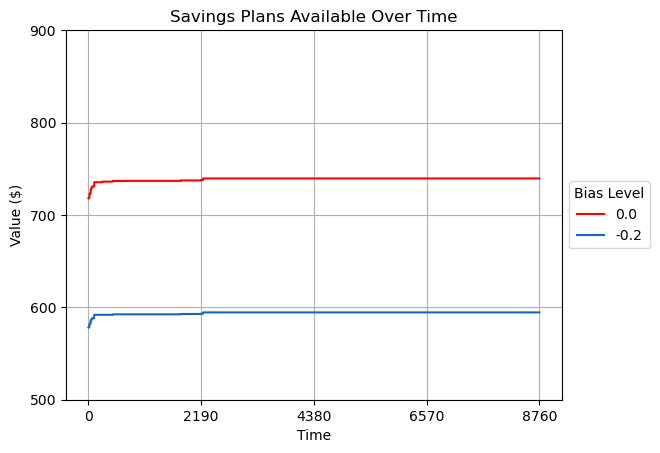

In [342]:
plt.plot(df_sp_purchases.index, df_sp_purchases[base_scenario], label='0.0', color=color_base)
plt.plot(df_sp_purchases.index, df_sp_purchases[scenario], label='-0.2', color=color_scenario)

plt.xlabel("Time")
plt.ylabel("Value ($)")
plt.title("Savings Plans Available Over Time")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.xticks(ticks=range(0, len(df_sp_purchases.index) + 1, 2190))
plt.yticks(ticks=range(500, 900+1, 100))

plt.show()

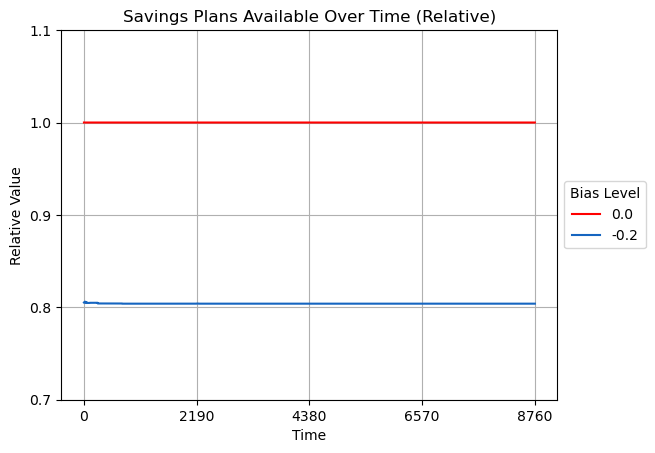

In [343]:
df_relative_sp_purchases = df_sp_purchases.div(df_sp_purchases[base_scenario], axis=0)

plt.plot(df_relative_sp_purchases.index, df_relative_sp_purchases[base_scenario], label='0.0', color=color_base)
plt.plot(df_relative_sp_purchases.index, df_relative_sp_purchases[scenario], label='-0.2', color=color_scenario)

plt.xlabel("Time")
plt.ylabel("Relative Value")
plt.title("Savings Plans Available Over Time (Relative)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.xticks(ticks=range(0, len(df_relative_sp_purchases.index) + 1, 2190))
#plt.yticks(ticks=[0.7, 0.8, 0.90, 1.00, 1.10, 1.20, 1.30])
plt.yticks(ticks=[0.7, 0.8, 0.90, 1.00, 1.10])


plt.show()

##### Idle Savings Plans

In [315]:
sp_usage_path = 'output/sp_usage'
df_sp_used = pd.DataFrame()

scenario_path = os.path.join(sp_usage_path, f'sp_usage_{scenario}.csv')
sp_used_scenario = pd.read_csv(scenario_path)

base_path = os.path.join(sp_usage_path, f'sp_usage_{base_scenario}.csv')
sp_used_base = pd.read_csv(base_path)

df_sp_used[scenario] = sp_used_scenario['value_used']
df_sp_used[base_scenario] = sp_used_base['value_used']

df_sp_idle = pd.DataFrame()
for col in df_sp_used.columns:
    df_sp_idle[col] = df_sp_purchases[col] - df_sp_used[col]

In [316]:
sp_usage_path = 'output/sp_usage'
df_sp_used = pd.DataFrame()

scenario_path = os.path.join(sp_usage_path, f'sp_usage_{scenario}.csv')
sp_used_scenario = pd.read_csv(scenario_path)

base_path = os.path.join(sp_usage_path, f'sp_usage_{base_scenario}.csv')
sp_used_base = pd.read_csv(base_path)

df_sp_used[scenario] = sp_used_scenario['value_used']
df_sp_used[base_scenario] = sp_used_base['value_used']

df_sp_idle = pd.DataFrame()
for col in df_sp_used.columns:
    df_sp_idle[col] = df_sp_purchases[col] - df_sp_used[col]

In [317]:
df_sp_idle.head()

,bias_-0.2_sd_0.0,bias_0.0_sd_0.0
0,2.62643,2.85366
1,4.14601,10.65918
2,4.20850,13.74729
3,4.83959,21.58793
4,5.46039,19.04207


In [318]:
print('Idle SP - -0.2:', float(df_sp_idle[[scenario]].sum()))
print('Idle SP - 0.0:', float(df_sp_idle[[base_scenario]].sum()))

Idle SP - -0.2: 269299.11317999987
Idle SP - 0.0: 627000.4871400009


/tmp/ipykernel_481136/1751155770.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Idle SP - -0.2:', float(df_sp_idle[[scenario]].sum()))
/tmp/ipykernel_481136/1751155770.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Idle SP - 0.0:', float(df_sp_idle[[base_scenario]].sum()))


In [349]:
print('Decrease in idle savings plans:', float(df_sp_idle[[base_scenario]].sum()) - float(df_sp_idle[[scenario]].sum()))

Decrease in idle savings plans: 357701.37396000104


/tmp/ipykernel_481136/3644720528.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Decrease in idle savings plans:', float(df_sp_idle[[base_scenario]].sum()) - float(df_sp_idle[[scenario]].sum()))
/tmp/ipykernel_481136/3644720528.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Decrease in idle savings plans:', float(df_sp_idle[[base_scenario]].sum()) - float(df_sp_idle[[scenario]].sum()))


In [319]:
print('Used SP - -0.2:', float(df_sp_used[[scenario]].sum()))
print('Used SP - 0.0:', float(df_sp_used[[base_scenario]].sum()))

Used SP - -0.2: 4932964.03922
Used SP - 0.0: 5843527.2287099995


/tmp/ipykernel_481136/1590309904.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Used SP - -0.2:', float(df_sp_used[[scenario]].sum()))
/tmp/ipykernel_481136/1590309904.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Used SP - 0.0:', float(df_sp_used[[base_scenario]].sum()))


In [348]:
print('Decrease in savings plans usage:',  float(df_sp_used[[base_scenario]].sum()) - float(df_sp_used[[scenario]].sum()))

Decrease in savings plans usage: 910563.1894899998


/tmp/ipykernel_481136/3517341808.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Decrease in savings plans usage:',  float(df_sp_used[[base_scenario]].sum()) - float(df_sp_used[[scenario]].sum()))
/tmp/ipykernel_481136/3517341808.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Decrease in savings plans usage:',  float(df_sp_used[[base_scenario]].sum()) - float(df_sp_used[[scenario]].sum()))


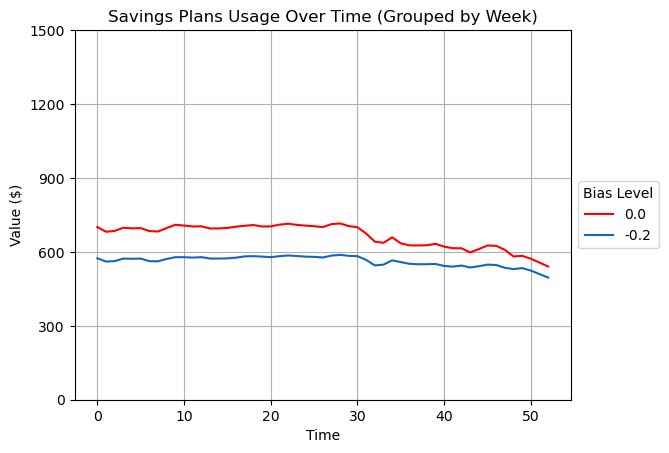

In [345]:
n = 24*7
df_sp_used_grouped = df_sp_used.groupby(df_sp_used.index // n).mean()

plt.plot(df_sp_used_grouped.index, df_sp_used_grouped[base_scenario], label='0.0', color=color_base)
plt.plot(df_sp_used_grouped.index, df_sp_used_grouped[scenario], label='-0.2', color=color_scenario)

plt.xlabel("Time")
plt.ylabel("Value ($)")
plt.title("Savings Plans Usage Over Time (Grouped by Week)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.yticks(ticks=range(0, 1500+1, 300))

plt.show()

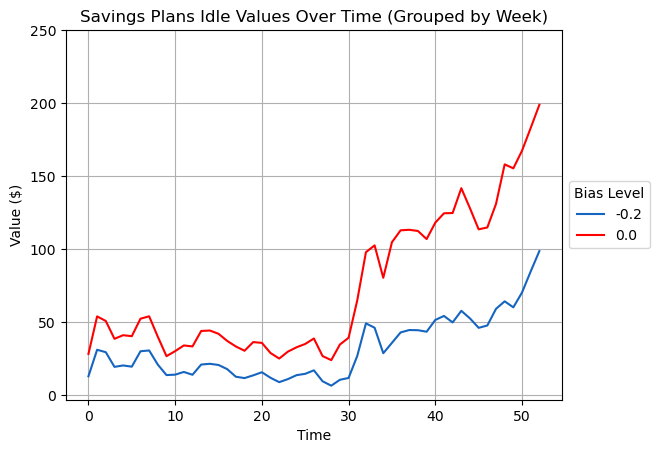

In [346]:
n = 24*7
df_sp_idle_grouped = df_sp_idle.groupby(df_sp_idle.index // n).mean()


plt.plot(df_sp_idle_grouped.index, df_sp_idle_grouped[scenario], label='-0.2', color=color_scenario)
plt.plot(df_sp_idle_grouped.index, df_sp_idle_grouped[base_scenario], label='0.0', color=color_base)

plt.xlabel("Time")
plt.ylabel("Value ($)")
plt.title("Savings Plans Idle Values Over Time (Grouped by Week)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.yticks(ticks=range(0, 250 + 1, 50))

plt.show()

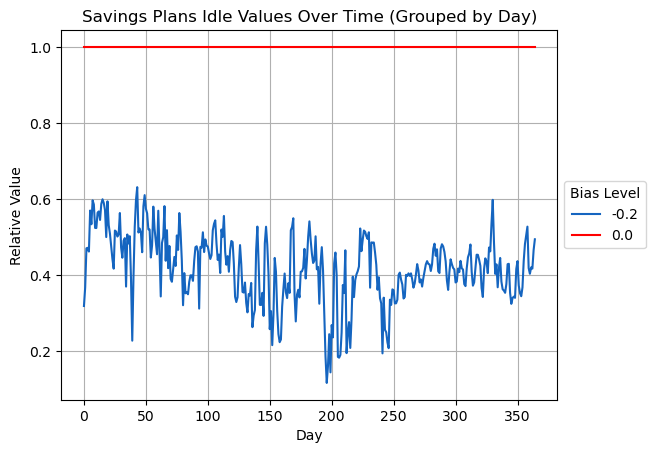

In [322]:
df_sp_idle_relative = df_sp_idle.div(df_sp_idle[base_scenario], axis=0)

n = 24
df_sp_idle_relative_grouped = df_sp_idle_relative.groupby(df_sp_idle_relative.index // n).mean()

plt.plot(df_sp_idle_relative_grouped.index, df_sp_idle_relative_grouped[scenario], label='-0.2', color=color_scenario)
plt.plot(df_sp_idle_relative_grouped.index, df_sp_idle_relative_grouped[base_scenario], label='0.0', color=color_base)

plt.xlabel("Day")
plt.ylabel("Relative Value")
plt.title("Savings Plans Idle Values Over Time (Grouped by Day)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

#plt.yticks(ticks=range(1, 8, 1))

plt.show()

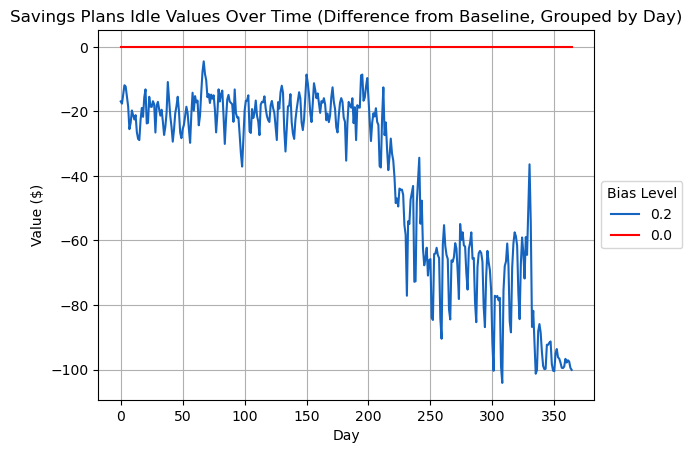

In [323]:
df_sp_idle_diff = df_sp_idle.sub(df_sp_idle[base_scenario], axis=0)

n = 24
df_sp_idle_diff_grouped = df_sp_idle_diff.groupby(df_sp_idle_diff.index // n).mean()

plt.plot(df_sp_idle_diff_grouped.index, df_sp_idle_diff_grouped[scenario], label='0.2', color=color_scenario)
plt.plot(df_sp_idle_diff_grouped.index, df_sp_idle_diff_grouped[base_scenario], label='0.0', color=color_base)

plt.xlabel("Day")
plt.ylabel("Value ($)")
plt.title("Savings Plans Idle Values Over Time (Difference from Baseline, Grouped by Day)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

#plt.yticks(ticks=range(1, 8, 1))

plt.show()

In [324]:
df_sp_idle.head()

,bias_-0.2_sd_0.0,bias_0.0_sd_0.0
0,2.62643,2.85366
1,4.14601,10.65918
2,4.20850,13.74729
3,4.83959,21.58793
4,5.46039,19.04207


In [325]:
df_sp_idle[scenario] = pd.to_numeric(df_sp_idle[scenario], errors="coerce")
total_idle_scenario = df_sp_idle[scenario].sum()
print(total_idle_scenario)

269299.11317999987


In [326]:
df_sp_idle[base_scenario] = pd.to_numeric(df_sp_idle[base_scenario], errors="coerce")
total_idle_base = df_sp_idle[base_scenario].sum()
print(total_idle_base)

627000.4871400009


In [327]:
print(total_idle_scenario - total_idle_base)

-357701.37396000104


In [328]:
print(total_idle_scenario / total_idle_base)

0.42950383405343184


In [329]:
total_idle_base * 0.58

363660.2825412005

##### On-demand Usage

In [330]:
allocations_path = 'output/allocations'
df_od_usage = pd.DataFrame()

scenario_path = os.path.join(allocations_path, f'alloc_cost_{scenario}.csv')
allocations_scenario = pd.read_csv(scenario_path)

base_path = os.path.join(allocations_path, f'alloc_cost_{base_scenario}.csv')
allocations_base = pd.read_csv(base_path)

df_od_usage[scenario] = allocations_scenario['OnDemand']
df_od_usage[base_scenario] = allocations_base['OnDemand']

In [331]:
allocations_scenario.head()

,timestamp,OnDemand,RAll,RPartialUp,RPartialHr,RNo,AllMarkets
0,0,846.11363,0.0,0.0,0.0,578.20974,1424.32337
1,1,767.77513,0.0,0.0,0.0,578.47794,1346.25307
2,2,823.38163,0.0,0.0,0.0,578.47794,1401.85957
3,3,769.01843,0.0,0.0,0.0,578.47794,1347.49637
4,4,763.12053,0.0,0.0,0.0,578.47794,1341.59847


In [332]:

float(allocations_base[['RNo']].sum())

/tmp/ipykernel_481136/3976553212.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(allocations_base[['RNo']].sum())


6470527.715850002

In [333]:
df_od_usage.head()

,bias_-0.2_sd_0.0,bias_0.0_sd_0.0
0,846.11363,626.71403
1,767.77513,558.14383
2,823.38163,618.30853
3,769.01843,575.14183
4,763.12053,564.16893


In [334]:
df_od_usage[scenario] = pd.to_numeric(df_od_usage[scenario], errors="coerce")
total_usage_scenario = df_od_usage[scenario].sum()
print(total_usage_scenario)

7705087.66272


In [335]:
df_od_usage[base_scenario] = pd.to_numeric(df_od_usage[base_scenario], errors="coerce")
total_usage_base = df_od_usage[base_scenario].sum()
print(total_usage_base)

6275532.38372


In [347]:
print('Increase in on-demand usage:', total_usage_scenario - total_usage_base)

Increase in on-demand usage: 1429555.279


In [337]:
print(total_usage_scenario / total_usage_base)

1.2277982474775455


In [338]:
print(float(allocations_scenario[['OnDemand']].sum()))
print(float(allocations_scenario[['RNo']].sum()))
print(float(allocations_scenario[['AllMarkets']].sum()))

7705087.66272
5202263.1524
12907350.81512


/tmp/ipykernel_481136/1208789045.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_scenario[['OnDemand']].sum()))
/tmp/ipykernel_481136/1208789045.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_scenario[['RNo']].sum()))
/tmp/ipykernel_481136/1208789045.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_scenario[['AllMarkets']].sum()))


In [339]:
print(float(allocations_base[['OnDemand']].sum()))
print(float(allocations_base[['RNo']].sum()))
print(float(allocations_base[['AllMarkets']].sum()))

6275532.38372
6470527.715850002
12746060.099569999


/tmp/ipykernel_481136/2071417821.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_base[['OnDemand']].sum()))
/tmp/ipykernel_481136/2071417821.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_base[['RNo']].sum()))
/tmp/ipykernel_481136/2071417821.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(allocations_base[['AllMarkets']].sum()))


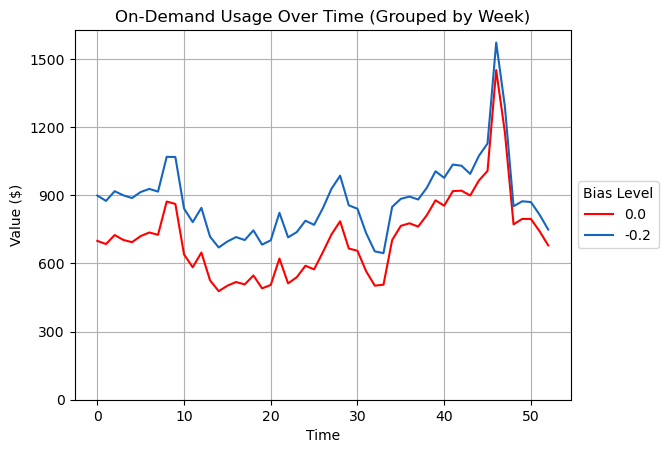

In [344]:
n = 24*7
df_od_usage_grouped = df_od_usage.groupby(df_od_usage.index // n).mean()

plt.plot(df_od_usage_grouped.index, df_od_usage_grouped[base_scenario], label='0.0', color=color_base)
plt.plot(df_od_usage_grouped.index, df_od_usage_grouped[scenario], label='-0.2', color=color_scenario)

plt.xlabel("Time")
plt.ylabel("Value ($)")
plt.title("On-Demand Usage Over Time (Grouped by Week)")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.yticks(ticks=range(0, 1500+1, 300))

plt.show()

##### Demand Relative to Savings Plans

In [ ]:
demand_path = 'output/demand_sp_cost'
base = 'bias_0.0_sd_0.0'

df_dem_cost = pd.read_csv(os.path.join(demand_path, f'demand_{base}_sp_cost.csv'))

scenario = 'bias_0.2_sd_0.0'
scenario_path = os.path.join(allocations_path, f'alloc_cost_{scenario}.csv')
allocations_scenario = pd.read_csv(scenario_path)

base_path = os.path.join(allocations_path, f'alloc_cost_{base}.csv')
allocations_base = pd.read_csv(base_path)

In [352]:
df_dem_cost

,timestamp,num_instances
0,1672531200,1332.76535
1,1672534800,1272.65469
2,1672538400,1312.29949
3,1672542000,1272.81345
4,1672545600,1264.80311
...,...,...
8755,1704049200,1213.00276
8756,1704052800,1196.82090
8757,1704056400,1178.82732
8758,1704060000,1157.32239


KeyError: 'bias_0.2_sd_0.0'

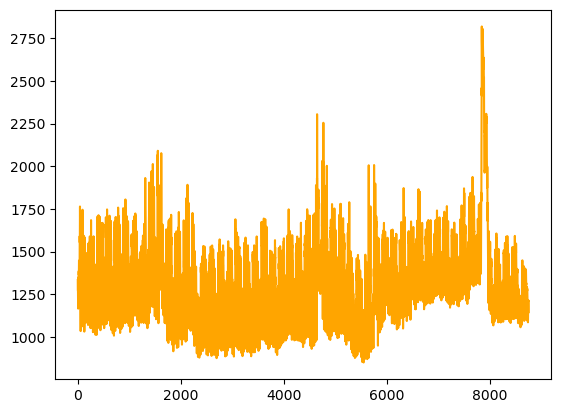

In [ ]:
#n = 24*7
#df_od_usage_grouped = df_od_usage.groupby(df_od_usage.index // n).mean()

plt.plot(df_dem_cost.index, df_dem_cost['num_instances'], color='orange')

plt.plot(allocations_scenario.index, allocations_scenario[scenario], label='-0.2', color=color_scenario)
plt.plot(allocations_base.index, allocations_base[base], label='0.0', color=color_base)

plt.xlabel("Time")
plt.ylabel("Value ($)")
plt.title("Demand vs Savings Plans Purchase")
plt.legend(title='Bias Level', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

#plt.yticks(ticks=range(0, 1500+1, 300))

plt.show()